# Double DQN

In [1]:
import torch
import r2l
import numpy as np
import random
import matplotlib.pyplot as plt
import gymnasium as gym
import rl_utils

In [2]:
lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 50
buffer_size = 5000
minimal_size = 1000
batch_size = 64
device = r2l.get_gpu()

env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = 11 # 连续动作被划分成 11 个

Iterstion: 9: 100%|██████████| 20/20 [00:03<00:00,  5.61it/s, episode=200, return=-206.732]


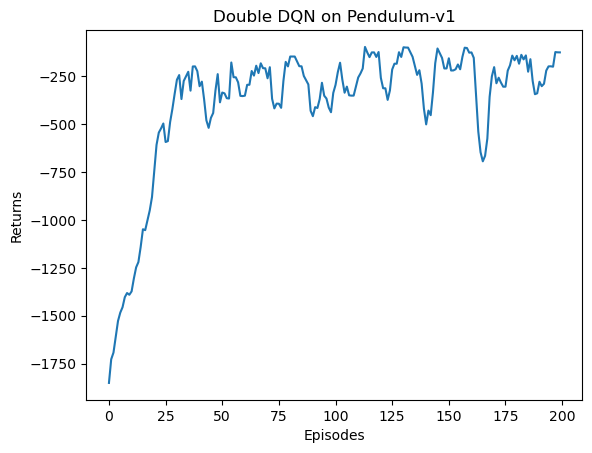

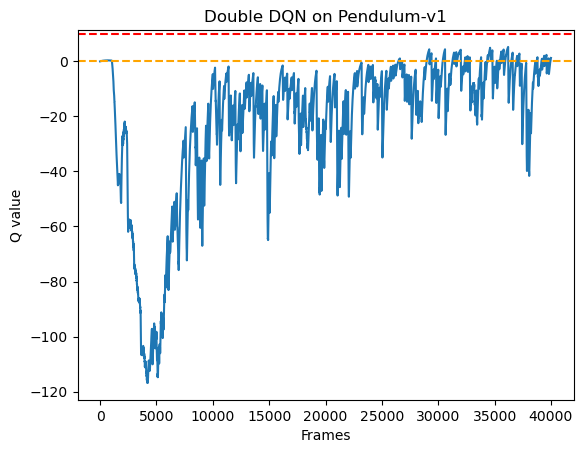

In [3]:
random.seed(0)
np.random.seed(0)
env.reset(seed=0)
torch.manual_seed(0)
replay_buffer = r2l.ReplayBuffer(buffer_size)
agent = r2l.DQN_D(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device, dqn_type='DoubleDQN')
return_list, max_q_value_list = r2l.train_dqn(agent, env, num_episodes, replay_buffer, minimal_size, batch_size)

episode_list = list(range(len(return_list)))
mv_return = rl_utils.moving_average(return_list, 5)
plt.plot(episode_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Double DQN on {}'.format(env_name))
plt.show()

frames_list = list(range(len(max_q_value_list)))
plt.plot(frames_list, max_q_value_list)
plt.axhline(0, c='orange', ls='-'
'-')
plt.axhline(10, c='red', ls='--')
plt.xlabel('Frames')
plt.ylabel('Q value')
plt.title('Double DQN on {}'.format(env_name))
plt.show()